# CS301 Project: Subset Sum
## Algorithm Experiments

This notebook contains experiments of:
1. **Brute Force:** Bitmask enumeration (exact, O(n · 2ⁿ))
2. **Heuristic:** APPROX-SUBSET-SUM from CLRS Chapter 35.5 (FPTAS, polynomial in n, log t, 1/ε)

Both algorithms solve the optimization version of Subset Sum: given a set S of positive integers and a target t, find a subset of S whose sum is as large as possible without exceeding t.

## 1. Brute Force: Bitmask Enumeration

Iterates over all integers from 0 to 2ⁿ − 1. Each integer represents a subset via its binary representation: bit i is 1 iff element xᵢ is included. Computes the sum of selected elements and tracks the maximum feasible sum (≤ t).

- **Time complexity:** Θ(n · 2ⁿ)
- **Space complexity:** Θ(n)
- **Correctness:** Examines every subset of S exactly once; returns the maximum feasible sum.

In [2]:
from brute_force import brute_force_subset_sum

In [4]:
# Sanity check: example from CLRS page 1129
S = [1, 4, 5]
t = 9
result_sum, result_subset = brute_force_subset_sum(S, t)
print(f"S = {S}, t = {t}")
print(f"Best sum: {result_sum}")
print(f"Subset: {result_subset}")
# Expected: best sum = 9, subset = [4, 5]

S = [1, 4, 5], t = 9
Best sum: 9
Subset: [4, 5]


## 2. Heuristic: APPROX-SUBSET-SUM (CLRS 35.5)

A fully polynomial-time approximation scheme (FPTAS) that returns a value z satisfying  
z*/(1+ε) ≤ z ≤ z*, where z* is the true optimum.

**Strategy:** Maintain a sorted list L of reachable subset sums. After processing each element xᵢ, merge L with L + xᵢ and trim near-duplicate values to keep |L| polynomial.

**TRIM(L, δ)** keeps element y only if it differs from the last kept element by more than a factor of (1 + δ).

- **Time complexity:** O((n³ log t) / ε) [CLRS Theorem 35.8]
- **Space complexity:** O((n log t) / ε)
- **Approximation ratio:** (1 + ε) — i.e., z*/(1+ε) ≤ output ≤ z*

In [5]:
from heuristic import trim
from heuristic import approx_subset_sum

In [6]:
# Sanity check: TRIM example from CLRS page 1130
L = [10, 11, 12, 15, 20, 21, 22, 23, 24, 29]
delta = 0.1
expected = [10, 12, 15, 20, 23, 29]
result = trim(L, delta)
print(f"Input:    {L}")
print(f"Output:   {result}")
print(f"Expected: {expected}")
print(f"Match: {result == expected}")

Input:    [10, 11, 12, 15, 20, 21, 22, 23, 24, 29]
Output:   [10, 12, 15, 20, 23, 29]
Expected: [10, 12, 15, 20, 23, 29]
Match: True


In [7]:
# Sanity check: example from CLRS page 1131
S = [104, 102, 201, 101]
t = 308
epsilon = 0.40

approx_result = approx_subset_sum(S, t, epsilon)
exact_result, exact_subset = brute_force_subset_sum(S, t)

print(f"S = {S}, t = {t}, ε = {epsilon}")
print(f"Approximate result: {approx_result}")
print(f"Exact result:       {exact_result} (subset: {exact_subset})")
print(f"Ratio (approx/exact): {approx_result / exact_result:.4f}")
print(f"Within (1+ε) bound:   {exact_result / approx_result <= 1 + epsilon}")
# Expected from CLRS: approx returns 302, exact is 307, ratio ~0.984 (well within 1.40 bound)

S = [104, 102, 201, 101], t = 308, ε = 0.4
Approximate result: 302
Exact result:       307 (subset: [104, 102, 101])
Ratio (approx/exact): 0.9837
Within (1+ε) bound:   True


## 3. Quick Comparison

Run both algorithms on a small random instance and verify the heuristic's output falls within the theoretical bound.

In [10]:
import random
import time

In [19]:
random.seed(42)

n = 15
S = [random.randint(1, 100) for _ in range(20)]
t = sum(S) // 2
epsilon = 0.1

print(f"S = {S}")
print(f"t = {t}, ε = {epsilon}")
print()

start = time.perf_counter()
exact_sum, exact_subset = brute_force_subset_sum(S, t)
exact_time = time.perf_counter() - start

start = time.perf_counter()
approx_sum = approx_subset_sum(S, t, epsilon)
approx_time = time.perf_counter() - start

print(f"Brute force:  sum = {exact_sum},  time = {exact_time*1000:.2f} ms")
print(f"Heuristic:    sum = {approx_sum},  time = {approx_time*1000:.2f} ms")
print(f"Ratio:        approx/exact = {approx_sum / exact_sum:.4f}")
print(f"Bound check:  exact/approx = {exact_sum / approx_sum:.4f} ≤ {1 + epsilon}  → {exact_sum / approx_sum <= 1 + epsilon}")

S = [82, 15, 4, 95, 36, 32, 29, 18, 95, 14, 87, 95, 70, 12, 76, 55, 5, 4, 12, 28]
t = 432, ε = 0.1

Brute force:  sum = 432,  time = 1627.67 ms
Heuristic:    sum = 432,  time = 2.09 ms
Ratio:        approx/exact = 1.0000
Bound check:  exact/approx = 1.0000 ≤ 1.1  → True


## Sample Generator

In [1]:
from sample_generator import generate_instance

S, t = generate_instance(n=10, seed=42)
print(f"n = {len(S)}")
print(f"S = {S}")
print(f"t = {t}")
print(f"sum(S) = {sum(S)}")
print(f"max(S) = {max(S)}")
print(f"max(S) <= t: {max(S) <= t}")
print(f"sum(S) > t:  {sum(S) > t}")

n = 10
S = [655, 115, 26, 760, 282, 251, 229, 143, 755, 105]
t = 1660
sum(S) = 3321
max(S) = 760
max(S) <= t: True
sum(S) > t:  True


In [2]:
S1, t1 = generate_instance(n=20, seed=123)
S2, t2 = generate_instance(n=20, seed=123)
print(f"Same seed gives same instance: {S1 == S2 and t1 == t2}")

S3, t3 = generate_instance(n=20, seed=456)
print(f"Different seed gives different instance: {S1 != S3 or t1 != t3}")

Same seed gives same instance: True
Different seed gives different instance: True


In [3]:
for n in [5, 10, 50, 100, 1000]:
    S, t = generate_instance(n=n, max_weight=1000, seed=n)
    print(f"n={n:>5}: |S|={len(S):>5}, sum(S)={sum(S):>8}, t={t:>7}, max(S)={max(S):>5}")

n=    5: |S|=    5, sum(S)=    2843, t=   1421, max(S)=  815
n=   10: |S|=   10, sum(S)=    4186, t=   2093, max(S)=  833
n=   50: |S|=   50, sum(S)=   27347, t=  13673, max(S)=  996
n=  100: |S|=  100, sum(S)=   53120, t=  26560, max(S)=  994
n= 1000: |S|= 1000, sum(S)=  493784, t= 246892, max(S)=  998


In [4]:
from sample_generator import generate_instance
from brute_force import brute_force_subset_sum
from heuristic import approx_subset_sum

S, t = generate_instance(n=15, seed=7)
exact_sum, _ = brute_force_subset_sum(S, t)
approx_sum = approx_subset_sum(S, t, epsilon=0.1)

print(f"Generated: n=20, t={t}, sum(S)={sum(S)}")
print(f"Exact:  {exact_sum}")
print(f"Approx: {approx_sum}")
print(f"Ratio:  {approx_sum / exact_sum:.4f}")

Generated: n=20, t=3313, sum(S)=6626
Exact:  3313
Approx: 3302
Ratio:  0.9967


## Performance Analysis

Analysis of timing data from `data/performance_data.csv`. For each input size n, we compute the sample mean runtime, 95% confidence interval, and the b/a ratio (where the CI is [a−b, a+b]). The project requires b/a < 0.1 for every n.

We then fit a power-law model T(n) = c · n^k to the mean runtimes and derive an empirical running-time expression.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Load raw timing data
df = pd.read_csv("data/performance_data.csv")
print(f"Loaded {len(df)} rows")
print(f"n values: {sorted(df['n'].unique())}")
print(f"Trials per n: {df.groupby('n').size().to_dict()}")
df.head()

Loaded 300 rows
n values: [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(5000), np.int64(10000)]
Trials per n: {10: 30, 20: 30, 50: 30, 100: 30, 200: 30, 500: 30, 1000: 30, 2000: 30, 5000: 30, 10000: 30}


,n,trial,seed,epsilon,runtime_seconds,result
0,10,0,100000,0.1,0.000413,2758
1,10,1,100001,0.1,0.000396,2634
2,10,2,100002,0.1,0.000371,2376
3,10,3,100003,0.1,0.000413,3223
4,10,4,100004,0.1,0.000227,2001


### Aggregation: mean, 95% CI, b/a ratio

For each n we compute:
- **Mean** runtime over all trials at that size.
- **95% confidence interval** for the mean, using Student's t-distribution (appropriate for small samples and unknown population variance).
- **b/a ratio**, where a is the mean and b is the half-width of the CI. The project requires b/a < 0.1.

In [8]:
def compute_stats(group: pd.Series, confidence: float = 0.95) -> pd.Series:
    """Compute mean, CI half-width, and b/a ratio for a group of runtimes."""
    n_trials = len(group)
    mean = group.mean()
    sem = stats.sem(group)  # standard error of the mean
    # t-based CI half-width
    t_crit = stats.t.ppf((1 + confidence) / 2, df=n_trials - 1)
    half_width = t_crit * sem
    return pd.Series({
        "trials": n_trials,
        "mean_s": mean,
        "ci_low": mean - half_width,
        "ci_high": mean + half_width,
        "half_width_b": half_width,
        "b_over_a": half_width / mean if mean > 0 else float("inf"),
        "std_s": group.std(ddof=1),
    })

stats_df = df.groupby("n")["runtime_seconds"].apply(compute_stats).unstack()
stats_df = stats_df.reset_index()
stats_df

,n,trials,mean_s,ci_low,ci_high,half_width_b,b_over_a,std_s
0,10,30.0,0.000364,0.000337,0.000392,0.000028,0.075537,0.000074
1,20,30.0,0.006164,0.005772,0.006556,0.000392,0.063588,0.001050
2,50,30.0,0.076044,0.074130,0.077958,0.001914,0.025171,0.005126
3,100,30.0,0.410651,0.389847,0.431454,0.020804,0.050661,0.055714
4,200,30.0,1.778925,1.740991,1.816859,0.037934,0.021324,0.101589
5,500,30.0,13.570223,13.135637,14.004809,0.434586,0.032025,1.163843
6,1000,30.0,75.517483,73.781298,77.253668,1.736185,0.022991,4.649588
7,2000,30.0,314.956809,312.730334,317.183283,2.226475,0.007069,5.962609
8,5000,30.0,2051.326246,2011.859317,2090.793174,39.466928,0.019240,105.694376
9,10000,30.0,8825.296710,8015.570910,9635.022510,809.725800,0.091751,2168.485518


In [9]:
violations = stats_df[stats_df["b_over_a"] >= 0.1]
if len(violations) == 0:
    print("✓ All sizes satisfy b/a < 0.1")
else:
    print("✗ The following sizes have b/a ≥ 0.1 and need more trials:")
    print(violations[["n", "trials", "mean_s", "b_over_a"]])

✓ All sizes satisfy b/a < 0.1


### Summary table for the report

The table below summarizes the timing measurements: number of trials, mean runtime, 95% CI, and b/a ratio at each input size. This is the table to include in Section 6 of the report.

In [10]:
def fmt_seconds(x):
    """Pretty-print times in s, ms, or µs."""
    if x >= 1:
        return f"{x:.3f} s"
    elif x >= 1e-3:
        return f"{x*1e3:.2f} ms"
    else:
        return f"{x*1e6:.1f} µs"

report_table = pd.DataFrame({
    "n": stats_df["n"].astype(int),
    "trials": stats_df["trials"].astype(int),
    "mean runtime": stats_df["mean_s"].apply(fmt_seconds),
    "95% CI": [
        f"[{fmt_seconds(lo)}, {fmt_seconds(hi)}]"
        for lo, hi in zip(stats_df["ci_low"], stats_df["ci_high"])
    ],
    "b/a": stats_df["b_over_a"].apply(lambda x: f"{x:.4f}"),
})
report_table

,n,trials,mean runtime,95% CI,b/a
0,10,30,364.3 µs,"[336.7 µs, 391.8 µs]",0.0755
1,20,30,6.16 ms,"[5.77 ms, 6.56 ms]",0.0636
2,50,30,76.04 ms,"[74.13 ms, 77.96 ms]",0.0252
3,100,30,410.65 ms,"[389.85 ms, 431.45 ms]",0.0507
4,200,30,1.779 s,"[1.741 s, 1.817 s]",0.0213
5,500,30,13.570 s,"[13.136 s, 14.005 s]",0.0320
6,1000,30,75.517 s,"[73.781 s, 77.254 s]",0.0230
7,2000,30,314.957 s,"[312.730 s, 317.183 s]",0.0071
8,5000,30,2051.326 s,"[2011.859 s, 2090.793 s]",0.0192
9,10000,30,8825.297 s,"[8015.571 s, 9635.023 s]",0.0918


### Curve fitting: power-law model

The theoretical complexity of APPROX-SUBSET-SUM is O(n² log t / ε) (or O(n³ log t / ε) by a looser accounting; see Section 3.2.2). Both forms predict polynomial growth in n with a small exponent.

We fit a power-law model T(n) = c · n^k by performing linear regression in log-log space:

  log T(n) = log c + k · log n

The slope of the line is the empirical exponent k; the intercept gives c.

In [11]:
log_n = np.log(stats_df["n"].values)
log_t = np.log(stats_df["mean_s"].values)

# Linear regression in log-log space
slope, intercept, r_value, p_value, std_err = stats.linregress(log_n, log_t)

k = slope                  # empirical exponent
c = np.exp(intercept)      # empirical constant
r_squared = r_value ** 2

print(f"Empirical model: T(n) ≈ {c:.3e} · n^{k:.3f}")
print(f"R² = {r_squared:.4f}")
print(f"Slope std. error = {std_err:.4f}")
print()
print(f"Theoretical bounds: O(n² log t / ε)  and  O(n³ log t / ε)")
print(f"Empirical exponent k = {k:.3f}")

Empirical model: T(n) ≈ 4.556e-06 · n^2.371
R² = 0.9925
Slope std. error = 0.0729

Theoretical bounds: O(n² log t / ε)  and  O(n³ log t / ε)
Empirical exponent k = 2.371


### Visualization

Two plots:
1. **Linear-axis plot** with error bars — shows the overall growth and the spread of measurements.
2. **Log-log plot** with the fitted power-law line — shows that the data follows a polynomial trend and that the fit is good.

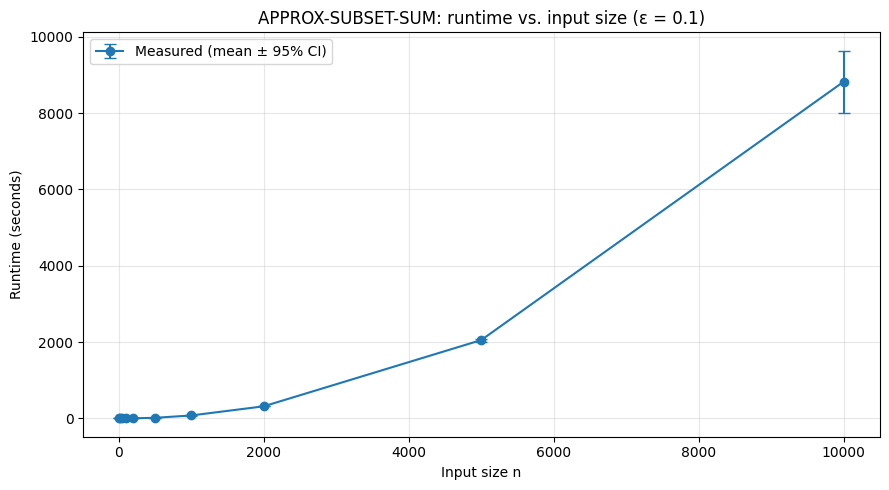

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(
    stats_df["n"],
    stats_df["mean_s"],
    yerr=stats_df["half_width_b"],
    fmt="o-",
    capsize=4,
    label="Measured (mean ± 95% CI)",
)

ax.set_xlabel("Input size n")
ax.set_ylabel("Runtime (seconds)")
ax.set_title("APPROX-SUBSET-SUM: runtime vs. input size (ε = 0.1)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/performance_linear.png", dpi=150, bbox_inches="tight")
plt.show()

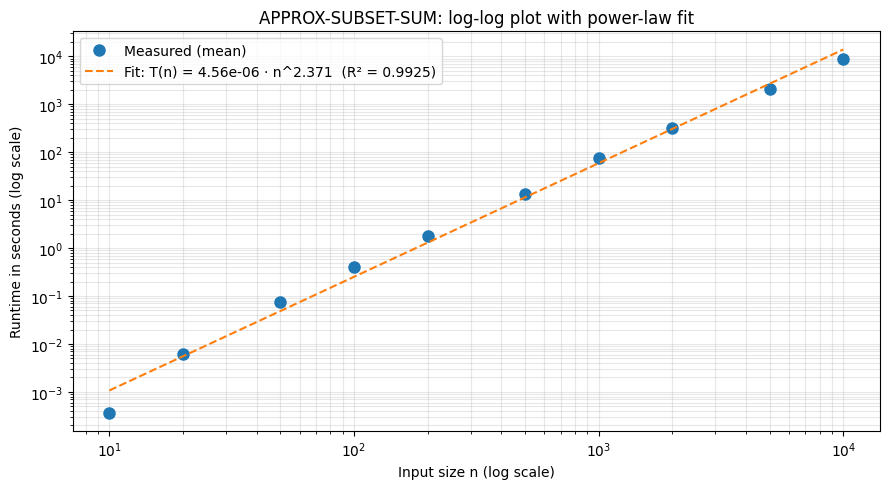

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter of measured points
ax.loglog(stats_df["n"], stats_df["mean_s"], "o", markersize=8, label="Measured (mean)")

# Fitted line
n_range = np.linspace(stats_df["n"].min(), stats_df["n"].max(), 100)
fitted = c * n_range ** k
ax.loglog(
    n_range,
    fitted,
    "--",
    label=f"Fit: T(n) = {c:.2e} · n^{k:.3f}  (R² = {r_squared:.4f})",
)

ax.set_xlabel("Input size n (log scale)")
ax.set_ylabel("Runtime in seconds (log scale)")
ax.set_title("APPROX-SUBSET-SUM: log-log plot with power-law fit")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("data/performance_loglog.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation

Compare the empirical exponent k to the theoretical bounds:
- If k ≈ 2, the empirical behavior matches the tighter O(n² log t / ε) prediction.
- If k ≈ 3, it matches the looser O(n³ log t / ε) bound from CLRS.
- The "log t" factor in the theoretical bound contributes additional growth because t grows linearly with n in our generator (t = sum(S) / 2, and sum(S) grows as n · max_weight / 2). This may push the empirical exponent slightly above the n^k portion of the prediction.

Save the empirical model expression — we'll include it directly in Section 6 of the report.

In [15]:
# Save the per-n summary statistics to a clean CSV for the report appendix
stats_df.to_csv("data/performance_summary.csv", index=False)
print("Saved aggregated stats to data/performance_summary.csv")

Saved aggregated stats to data/performance_summary.csv
